In [1]:
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Professional Data Science Theme
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'

# Corporate Colors
primary_color = "#2c3e50"    # Dark Blue/Grey
highlight_color = "#e74c3c"  # Red for outliers
success_color = "#27ae60"  # Green for growth

# Formatter for large numbers (Millions)
def currency_formatter(x, pos):
    return f'${x/1e6:.1f}M'

## Load the files

In [2]:
dimcity = pd.read_csv("DimCity_cleaned.csv")
dimcustomer = pd.read_csv("DimCustomer_cleaned.csv")
dimdate = pd.read_csv("DimDate_cleaned.csv")
dimemployee = pd.read_csv("DimEmployee_cleaned.csv")
dimstockItem = pd.read_csv("DimStockItem_cleaned.csv")
factsale = pd.read_csv("FactSale_cleaned.csv")

In [3]:
dimdate["Date"] = pd.to_datetime(dimdate["Date"])
factsale['Invoice Date Key'] = pd.to_datetime(factsale['Invoice Date Key'])
factsale['Delivery Date Key'] = pd.to_datetime(factsale['Delivery Date Key'])

In [4]:
print(f"factsales columns: \n{factsale.columns.tolist()}\n")
print(f"dimemployee columns: \n{dimemployee.columns.tolist()}\n")
print(f"dimcustomer columns: \n{dimcustomer.columns.tolist()}\n")
print(f"dimcity columns: \n{dimcity.columns.tolist()}\n")
print(f"dimdate columns: \n{dimdate.columns.tolist()}\n")
print(f"dimstockItem columns: \n{dimstockItem.columns.tolist()}")

factsales columns: 
['Sale Key', 'City Key', 'Customer Key', 'Bill To Customer Key', 'Stock Item Key', 'Invoice Date Key', 'Delivery Date Key', 'Salesperson Key', 'WWI Invoice ID', 'Description', 'Package', 'Quantity', 'Unit Price', 'Tax Rate', 'Total Excluding Tax', 'Tax Amount', 'Profit', 'Total Including Tax', 'Total Dry Items', 'Total Chiller Items', 'Lineage Key']

dimemployee columns: 
['Employee Key', 'WWI Employee ID', 'Employee', 'Preferred Name', 'Is Salesperson', 'Valid From', 'Valid To', 'Lineage Key']

dimcustomer columns: 
['Customer Key', 'WWI Customer ID', 'Customer', 'Bill To Customer', 'Category', 'Buying Group', 'Primary Contact', 'Postal Code', 'Credit Limit', 'Valid From', 'Valid To', 'Lineage Key']

dimcity columns: 
['City Key', 'City', 'State Province', 'Country', 'Sales Territory', 'Location', 'Latest Recorded Population']

dimdate columns: 
['Date', 'Day Number', 'Day', 'Month', 'Short Month', 'Calendar Month Number', 'Calendar Month Label', 'Calendar Year', '

In [5]:
factsale = factsale.drop(columns=['Lineage Key'], errors='ignore')
dimemployee = dimemployee.drop(columns=['Lineage Key'], errors='ignore')
dimcustomer = dimcustomer.drop(columns=['Lineage Key'], errors='ignore')
dimcity = dimcity.drop(columns=['Lineage Key'], errors='ignore')
dimdate = dimdate.drop(columns=['Lineage Key'], errors='ignore')
dimstockItem = dimstockItem.drop(columns=['Lineage Key'], errors='ignore')

## Build Analytical Dataset (Fact + Dimensions)

In [6]:
merge_df = factsale.merge(dimemployee, left_on='Salesperson Key', right_on='Employee Key', how='left') \
         .merge(dimcustomer, on='Customer Key', how='left') \
         .merge(dimcity, on='City Key', how='left') \
         .merge(dimdate, left_on='Invoice Date Key', right_on='Date', how='left') \
         .merge(dimstockItem, on='Stock Item Key', how='left')

## Employees Analysis

In [7]:
employee_sales = merge_df.groupby(['Employee Key', 'Employee'])\
    [['Quantity', 'Total Including Tax', 'Profit']].\
    agg(
        total_quantity=('Quantity', 'sum'),
        avg_quantity=('Quantity', 'mean'),
        total_profit=('Profit', 'sum'),
        total_revenue=('Total Including Tax', 'sum')).\
    sort_values(by='total_profit', ascending=False).reset_index(drop=False)

employee_sales[['total_quantity', 'total_profit', 'total_revenue']] = \
    employee_sales[['total_quantity', 'total_profit', 'total_revenue']].round().astype(int)

In [8]:
employee_sales.head(10)

,Employee Key,Employee,total_quantity,avg_quantity,total_profit,total_revenue
0,19,Archer Lamble,103800,38.949343,1010010,2305127
1,143,Kayla Woodcock,38725,37.817383,412209,948694
2,129,Taj Shand,41635,41.802209,375786,879454
3,119,Anthony Grosse,37711,39.779536,360396,833987
4,108,Amy Trefl,34720,37.616468,344132,773496
5,90,Hudson Hollinworth,27674,35.800776,303817,700885
6,93,Sophia Hinton,24903,38.489954,276868,646259
7,152,Lily Code,30725,37.607099,276256,657017
8,150,Jack Potter,26939,37.624302,255734,576430
9,86,Lily Code,23310,36.308411,250296,560145


In [9]:
employee_sales['Percentage_of_impact_on_profits'] = \
    (employee_sales['total_profit'] / employee_sales['total_profit'].sum()) * 100

In [10]:
employee_sales[['Percentage_of_impact_on_profits']].head(15)

,Percentage_of_impact_on_profits
0,10.177558
1,4.153703
2,3.786679
3,3.631599
4,3.467712
5,3.061470
6,2.789913
7,2.783746
8,2.576952
9,2.522155


In [11]:
employee_sales['Percentage_of_impact_on_profits'].head(15).sum()

np.float64(50.39354011575901)

#### Employees Insights:
- Archer Lamble significantly outperforms all other employees, achieving more than double the **profit**, **revenue**, and **units sold** of the second best performer.
- 15 employees make up **50%** of profits and Archer Lamble alone accounts for **10%** percent of the total profit
- There is a strong concentration of performance among top employees, indicating possible performance imbalance.

## Employee Visualization

C:\Users\LOQ\AppData\Local\Temp\ipykernel_20172\2340413533.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_15_emp, x='total_profit', y='Employee', palette=colors)
C:\Users\LOQ\AppData\Local\Temp\ipykernel_20172\2340413533.py:15: UserWarning: The palette list has more values (15) than needed (10), which may not be intended.
  ax = sns.barplot(data=top_15_emp, x='total_profit', y='Employee', palette=colors)


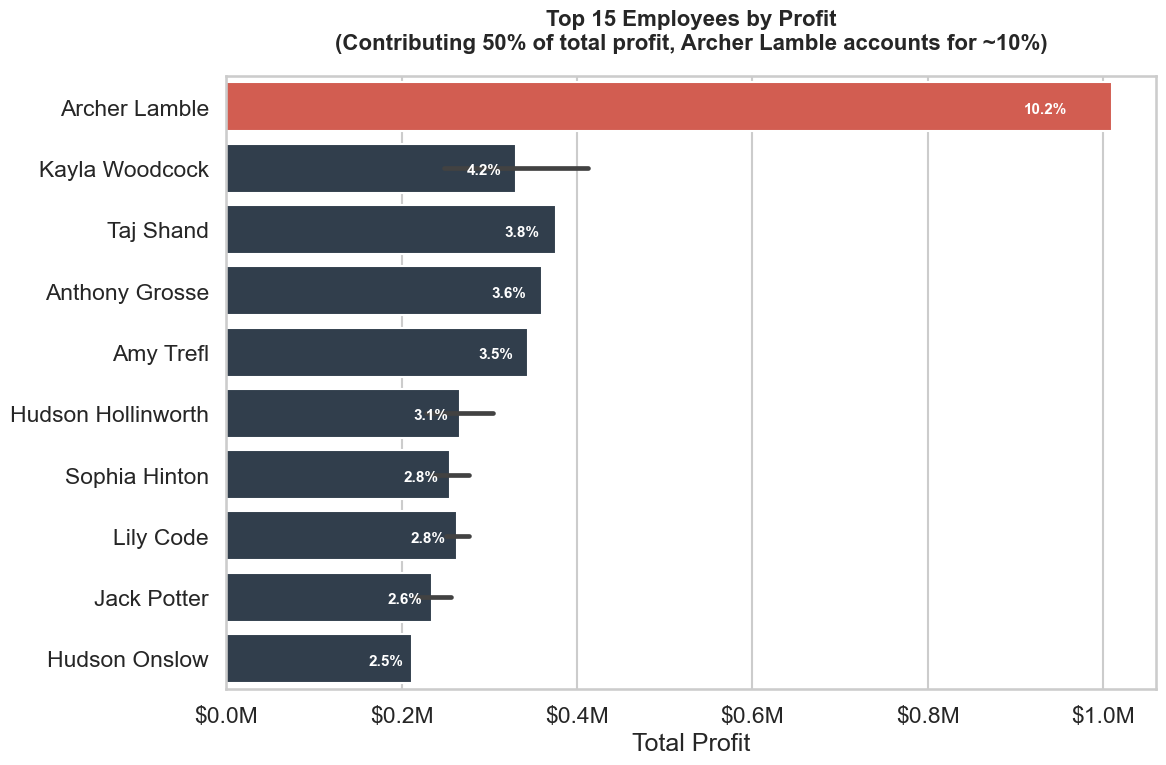

In [61]:
# 1. Select the top 15 employees based on your insight
top_15_emp = (
    employee_sales
    .sort_values(by='total_profit', ascending=False)
    .head(15)
    .copy()
)
#top_15_emp = employee_sales.head(15).copy()

plt.figure(figsize=(12, 8))

# 2. Logic: Highlight Archer Lamble to prove the anomaly
colors = [highlight_color if emp == 'Archer Lamble' else primary_color for emp in top_15_emp['Employee']]

ax = sns.barplot(data=top_15_emp, x='total_profit', y='Employee', palette=colors)
ax.xaxis.set_major_formatter(FuncFormatter(currency_formatter))

# 3. Add Professional Title and Subtitle based on your insights
plt.title('Top 15 Employees by Profit\n(Contributing 50% of total profit, Archer Lamble accounts for ~10%)', pad=20)
plt.xlabel('Total Profit')
plt.ylabel('')

# 4. Add the exact percentage of impact inside the bars for extra analytical depth
for p, index in zip(ax.patches, top_15_emp.index):
    width = p.get_width() #type: ignore
    percentage = top_15_emp.loc[index, 'Percentage_of_impact_on_profits']
    ax.text(width - (width * 0.05), p.get_y() + p.get_height()/2. + 0.1, #type: ignore
            f'{percentage:.1f}%', 
            ha="right", color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

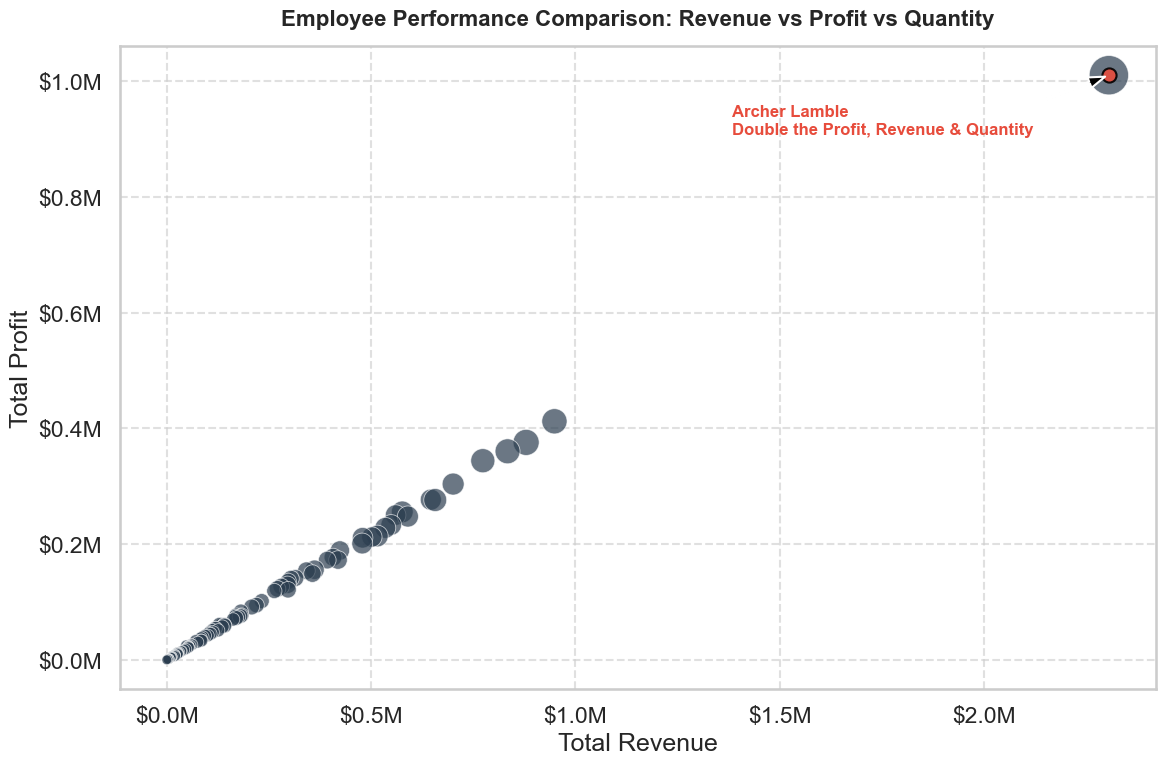

In [55]:
plt.figure(figsize=(12, 8))

# We use all employees here to show how far Archer is from the rest
# X = Revenue, Y = Profit, Size = Quantity
sns.scatterplot(
    data=employee_sales, 
    x='total_revenue', 
    y='total_profit', 
    size='total_quantity',
    sizes=(50, 800), # Control bubble size range
    alpha=0.7,
    color=primary_color,
    legend=False
)

# Highlight Archer Lamble specifically
archer_data = employee_sales[employee_sales['Employee'] == 'Archer Lamble']
plt.scatter(
    archer_data['total_revenue'], 
    archer_data['total_profit'], 
    s=archer_data['total_quantity'] / 1000, # scale down size for matplotlib
    color=highlight_color, 
    alpha=0.9, 
    edgecolor='black'
)

# Format axes to millions
ax = plt.gca()
ax.xaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax.yaxis.set_major_formatter(FuncFormatter(currency_formatter))

# Add an annotation (Arrow pointing to Archer)
plt.annotate(
    'Archer Lamble\nDouble the Profit, Revenue & Quantity', 
    xy=(archer_data['total_revenue'].values[0], archer_data['total_profit'].values[0]),
    xytext=(archer_data['total_revenue'].values[0] * 0.6, archer_data['total_profit'].values[0] * 0.9),
    arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
    fontsize=12,
    fontweight='bold',
    color=highlight_color
)

plt.title('Employee Performance Comparison: Revenue vs Profit vs Quantity', pad=15)
plt.xlabel('Total Revenue')
plt.ylabel('Total Profit')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Customers Analysis

In [12]:
customer_sales = merge_df.groupby(['Customer Key', 'Customer'])\
    [['Quantity', 'Total Including Tax', 'Profit']].\
    agg(
        total_quantity=('Quantity', 'sum'),
        avg_quantity=('Quantity', 'mean'),
        total_profit=('Profit', 'sum'),
        total_revenue=('Total Including Tax', 'sum')).\
    sort_values(by='total_profit', ascending=False).reset_index(drop=False)

customer_sales[['total_quantity', 'total_profit', 'total_revenue']] = \
    customer_sales[['total_quantity', 'total_profit', 'total_revenue']].round().astype(int)

In [13]:
# we have 49 customers in total
customer_sales.head(10)

,Customer Key,Customer,total_quantity,avg_quantity,total_profit,total_revenue
0,0,Unknown,356472,39.272006,3428607,7781876
1,273,"Wingtip Toys (San Jacinto, CA)",14870,37.361809,185159,408525
2,398,"Wingtip Toys (Haycock, AK)",14640,36.059113,167999,377386
3,102,"Tailspin Toys (Fieldbrook, CA)",17297,42.708642,163721,395483
4,281,"Wingtip Toys (Wapinitia, OR)",14402,38.715054,163085,394691
5,399,"Wingtip Toys (Kapa'a, HI)",15293,36.762019,161952,364315
6,384,"Wingtip Toys (Knights Landing, CA)",14098,34.218447,161495,376499
7,253,"Wingtip Toys (Lake Davis, CA)",16028,41.848564,160182,351162
8,98,"Tailspin Toys (El Centro, CA)",14429,40.304469,159568,343710
9,109,"Tailspin Toys (South Laguna, CA)",11146,35.496815,159068,361851


In [ ]:
# Percentage of profit from each customer
customer_sales['Percentage_of_profit'] = (customer_sales['total_profit'] / customer_sales['total_profit'].sum()) * 100

In [15]:
customer_sales.head(10)

,Customer Key,Customer,total_quantity,avg_quantity,total_profit,total_revenue,Percentage_of_profit
0,0,Unknown,356472,39.272006,3428607,7781876,34.549023
1,273,"Wingtip Toys (San Jacinto, CA)",14870,37.361809,185159,408525,1.865791
2,398,"Wingtip Toys (Haycock, AK)",14640,36.059113,167999,377386,1.692874
3,102,"Tailspin Toys (Fieldbrook, CA)",17297,42.708642,163721,395483,1.649766
4,281,"Wingtip Toys (Wapinitia, OR)",14402,38.715054,163085,394691,1.643358
5,399,"Wingtip Toys (Kapa'a, HI)",15293,36.762019,161952,364315,1.631941
6,384,"Wingtip Toys (Knights Landing, CA)",14098,34.218447,161495,376499,1.627336
7,253,"Wingtip Toys (Lake Davis, CA)",16028,41.848564,160182,351162,1.614105
8,98,"Tailspin Toys (El Centro, CA)",14429,40.304469,159568,343710,1.607918
9,109,"Tailspin Toys (South Laguna, CA)",11146,35.496815,159068,361851,1.602880


In [16]:
print(f'{"Total profit of the Unknown customers: ":<40}${customer_sales['total_profit'][0].sum()}')
print(f'{"Total profit of the rest customers: ":<40}${customer_sales['total_profit'][1:].sum()}')

Total profit of the Unknown customers:  $3428607
Total profit of the rest customers:     $6495283


#### Customer Insights

- There are **49** customers in total.

- Profit distribution is relatively consistent across **identified** customers, with no single dominant client.

- However, the "Unknown" customer is a major outlier, contributing approximately **34.5%** of total profit.

- The "Unknown" customer alone generates more than half the profit **($3,428,607)** of all other customers combined **($6,495,285)**, highlighting a significant gap in customer tracking and data quality.

## Customers Visualization

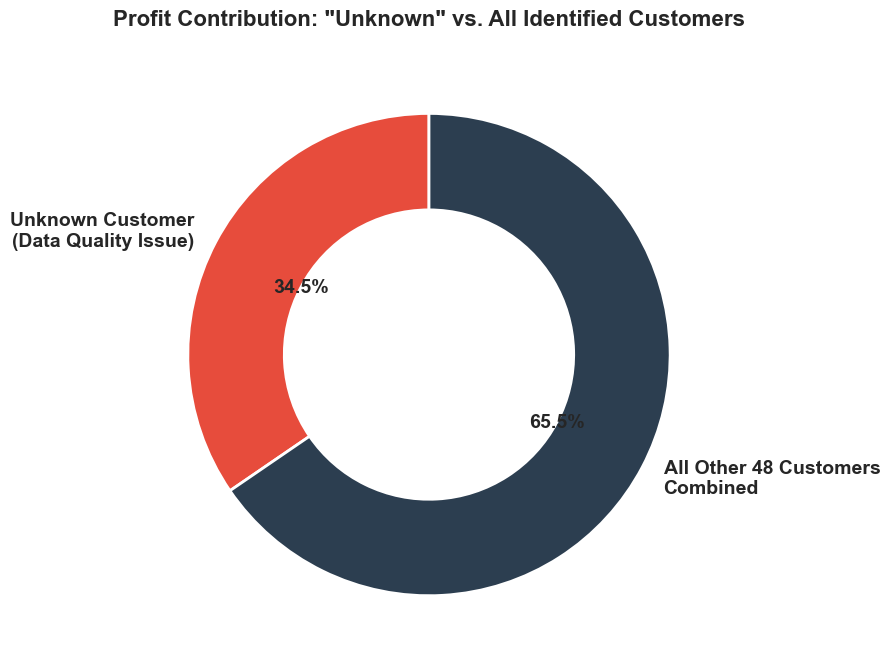

In [62]:
# 1. تجهيز الأرقام بناءً على الكود تبعك
unknown_profit = customer_sales.loc[0, 'total_profit']
rest_profit = customer_sales.loc[1:, 'total_profit'].sum()

data = [unknown_profit, rest_profit]
labels = ['Unknown Customer\n(Data Quality Issue)', 'All Other 48 Customers\nCombined']
colors = [highlight_color, primary_color] # استخدمنا الألوان من الثيم اللي فوق

# 2. رسم الدونات شارت
plt.figure(figsize=(9, 9))
plt.pie(data, labels=labels, colors=colors, autopct='%1.1f%%', 
        startangle=90, textprops={'fontsize': 14, 'weight': 'bold'},
        wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.4}) # width هو اللي بحول الـ Pie لـ Donut

plt.title('Profit Contribution: "Unknown" vs. All Identified Customers', pad=20)
plt.tight_layout()
plt.show()

C:\Users\LOQ\AppData\Local\Temp\ipykernel_20172\2016498706.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


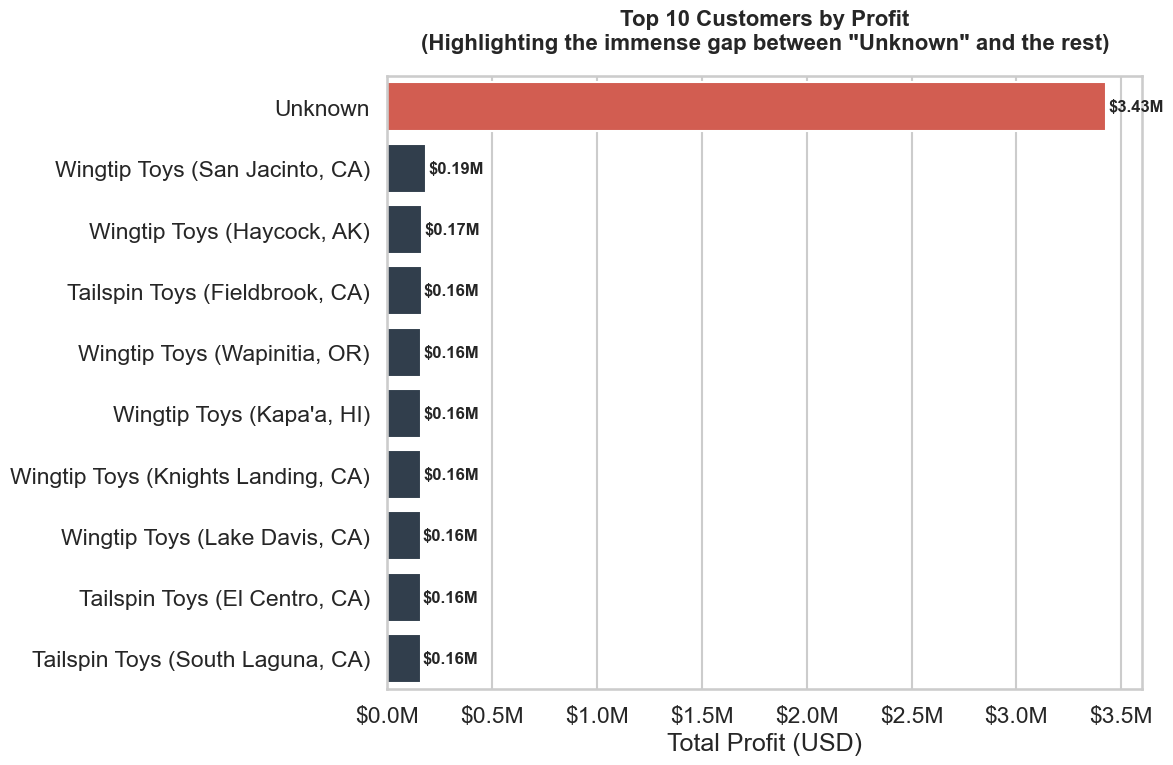

In [63]:
# 1. أخذ أعلى 10 عملاء لتوضيح الفكرة
top_10_cust = customer_sales.head(10).copy()

plt.figure(figsize=(12, 8))

# 2. تحديد الألوان (أحمر للمجهول، كحلي للباقي)
cust_colors = [highlight_color if cust == 'Unknown' else primary_color for cust in top_10_cust['Customer']]

# 3. الرسم مع استخدام order لضمان صحة طول البار 100%
ax = sns.barplot(
    data=top_10_cust, 
    x='total_profit', 
    y='Customer', 
    order=top_10_cust['Customer'], # السر لضبط الأطوال
    palette=cust_colors
)

# 4. إضافة الأرقام (Data Labels) للمصداقية
for p in ax.patches:
    width = p.get_width() #type: ignore
    ax.text(width + 10000, p.get_y() + p.get_height()/2,  #type: ignore
            f'${width/1e6:.2f}M', 
            va='center', fontsize=12, fontweight='bold')

# تنسيق المحور X
ax.xaxis.set_major_formatter(FuncFormatter(currency_formatter))

plt.title('Top 10 Customers by Profit\n(Highlighting the immense gap between "Unknown" and the rest)', pad=20)
plt.xlabel('Total Profit (USD)')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Buying Groups Analysis

In [17]:
category_sales = merge_df.groupby(['Buying Group'])\
    [['Quantity', 'Total Including Tax', 'Profit']].\
    agg(
        total_quantity=('Quantity', 'sum'),
        avg_quantity=('Quantity', 'mean'),
        total_profit=('Profit', 'sum'),
        total_revenue=('Total Including Tax', 'sum')).\
    sort_values(by='total_profit', ascending=False).reset_index(drop=False)

category_sales[['total_quantity', 'total_profit', 'total_revenue']] = \
    category_sales[['total_quantity', 'total_profit', 'total_revenue']].round().astype(int)

In [18]:
category_sales['profit_margin'] = category_sales['total_profit'] / category_sales['total_revenue']

In [19]:
category_sales.head()

,Buying Group,total_quantity,avg_quantity,total_profit,total_revenue,profit_margin
0,Tailspin Toys,418373,38.35821,3975493,9263496,0.429157
1,Wingtip Toys,253825,39.57976,2519792,5809706,0.433721


#### 	Buying Group Insights
- The business is highly concentrated around two major buying groups.
- All sales are concentrated in a single category: "Novelty Shop".
- Tailspin Toys sells more units than Wingtip Toys, but Wingtip Toys are more effective and profitable.
- Tailspin Toys operates as a high-volume driver, while Wingtip Toys delivers slightly better profit efficiency.

## Buying Groups Visualization

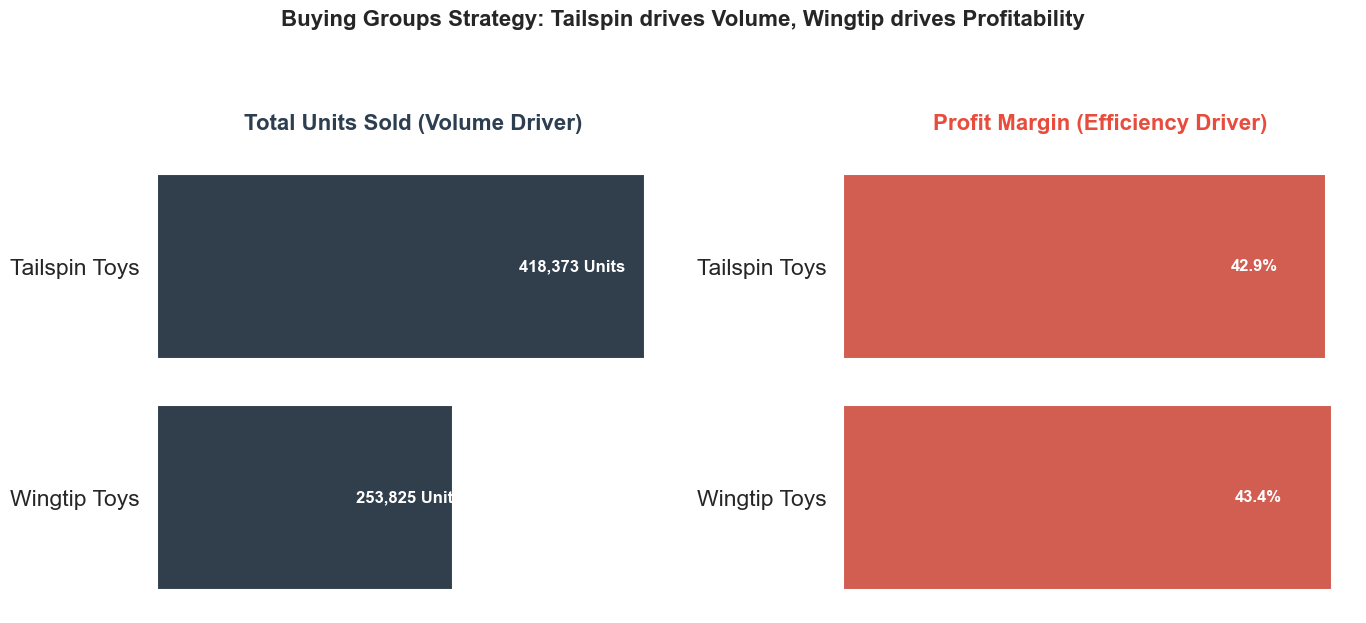

In [ ]:
from matplotlib.ticker import PercentFormatter

top_groups = category_sales.head(2).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(
    data=top_groups, 
    x='total_quantity', 
    y='Buying Group', 
    color=primary_color, 
    ax=ax1,
    order=top_groups['Buying Group']
)
ax1.set_title('Total Units Sold (Volume Driver)', fontweight='bold', color=primary_color, pad=15)
ax1.set_xlabel('')
ax1.set_ylabel('')
ax1.set_xticks([])

for p in ax1.patches:
    width = p.get_width()
    ax1.text(width - (width * 0.15), p.get_y() + p.get_height()/2, 
             f'{width:,.0f} Units', 
             ha="center", va="center", color='white', fontweight='bold', fontsize=12)

sns.barplot(
    data=top_groups, 
    x='profit_margin', 
    y='Buying Group', 
    color=highlight_color, 
    ax=ax2,
    order=top_groups['Buying Group']
)
ax2.set_title('Profit Margin (Efficiency Driver)', fontweight='bold', color=highlight_color, pad=15)
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.set_xticks([]) 

for p in ax2.patches:
    width = p.get_width()
    ax2.text(width - (width * 0.15), p.get_y() + p.get_height()/2, 
             f'{width*100:.1f}%', 
             ha="center", va="center", color='white', fontweight='bold', fontsize=12)


plt.suptitle('Buying Groups Strategy: Tailspin drives Volume, Wingtip drives Profitability', 
             fontsize=16, fontweight='bold', y=1.05)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

## Region Analysis

### State Analysis

In [20]:
state_sales = merge_df.groupby(['State Province'])\
    [['Quantity', 'Total Including Tax', 'Profit']].\
    agg(
        total_quantity=('Quantity', 'sum'),
        avg_quantity=('Quantity', 'mean'),
        total_profit=('Profit', 'sum'),
        total_revenue=('Total Including Tax', 'sum')).\
    sort_values(by='total_profit', ascending=False).\
    reset_index(drop=False)

state_sales[['total_quantity', 'total_profit', 'total_revenue']] = \
    state_sales[['total_quantity', 'total_profit', 'total_revenue']].round().astype(int)

In [21]:
state_sales['state_impact_on_profits'] = ((state_sales['total_profit'] / state_sales['total_profit'].sum()) * 100).round(1)

In [22]:
state_sales.shape

(6, 6)

In [67]:
state_sales.head(6)

,State Province,total_quantity,avg_quantity,total_profit,total_revenue,state_impact_on_profits
0,California,461064,38.839525,4434686,10153239,44.7
1,Washington,210392,38.824875,2093724,4859725,21.1
2,Alaska,159538,39.112037,1484470,3451302,15.0
3,Oregon,112041,39.618458,1121763,2588197,11.3
4,Nevada,70342,39.429372,627297,1438300,6.3
5,Hawaii,15293,36.762019,161952,364315,1.6


#### State Insights
- The market is concentrated in 6 states (California, Washington, Alaska, Oregon, Nevada, Hawaii)
- California is the dominant state, contributing approximately **44.7%** of total profit, making it the primary revenue and profit driver.
- The top 3 states (California, Washington, Alaska) account for the majority of total profit **(%81)**, indicating strong geographic concentration.


### City Analysis

In [24]:
city_sales = merge_df.groupby(['City'])\
    [['Quantity', 'Total Including Tax', 'Profit']].\
    agg(
        total_quantity=('Quantity', 'sum'),
        avg_quantity=('Quantity', 'mean'),
        total_profit=('Profit', 'sum'),
        total_revenue=('Total Including Tax', 'sum')).\
    sort_values(by='total_profit', ascending=False).\
    reset_index(drop=False)

city_sales[['total_quantity', 'total_profit', 'total_revenue']] = \
    city_sales[['total_quantity', 'total_profit', 'total_revenue']].round().astype(int)

In [25]:
city_sales['state_impact_on_profits'] = ((city_sales['total_profit'] / city_sales['total_profit'].sum()) * 100).round(1)

In [26]:
city_sales.shape

(75, 6)

In [27]:
city_sales.head(10)

,City,total_quantity,avg_quantity,total_profit,total_revenue,state_impact_on_profits
0,Akhiok,30999,42.348361,259554,623651,2.6
1,San Jacinto,14870,37.361809,185159,408525,1.9
2,Meadowdale,11913,36.542945,176754,373914,1.8
3,Haycock,14640,36.059113,167999,377386,1.7
4,Fieldbrook,17297,42.708642,163721,395483,1.6
5,Wapinitia,14402,38.715054,163085,394691,1.6
6,Kapa'a,15293,36.762019,161952,364315,1.6
7,Knights Landing,14098,34.218447,161495,376499,1.6
8,Caruthers,16587,39.212766,160276,359692,1.6
9,Lake Davis,16028,41.848564,160182,351162,1.6


In [28]:
city_sales.tail(10)

,City,total_quantity,avg_quantity,total_profit,total_revenue,state_impact_on_profits
65,Lemeta,11864,35.520958,107821,256825,1.1
66,Jesmond Dene,10649,31.320588,105012,238736,1.1
67,Lostine,11500,36.277603,104497,245023,1.1
68,Port Chilkoot,13757,43.952077,101490,237888,1.0
69,Biorka,11006,41.067164,90078,194761,0.9
70,Magalia,9588,35.120879,87740,210739,0.9
71,Marin City,11452,38.429530,82640,195103,0.8
72,Biggs,8627,42.920398,82191,190795,0.8
73,Long Beach,1576,54.344828,10155,26069,0.1
74,Midland,553,36.866667,3260,8326,0.0


#### City Insights

- City-level performance is relatively well distributed, with no single city dominating overall sales or profit.

- Profit and revenue are closely distributed among top cities, suggesting operational diversification across multiple locations.

- There is a noticeable gap between top and bottom cities, with some locations contributing minimally to total performance.

- Lower-performing cities may indicate areas with low demand or limited market penetration.

- While performance is concentrated at the state level, it is diversified across cities within those states, reducing localized operational risk.

## Region Visualization

### States Visualization

C:\Users\LOQ\AppData\Local\Temp\ipykernel_20172\3710316367.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


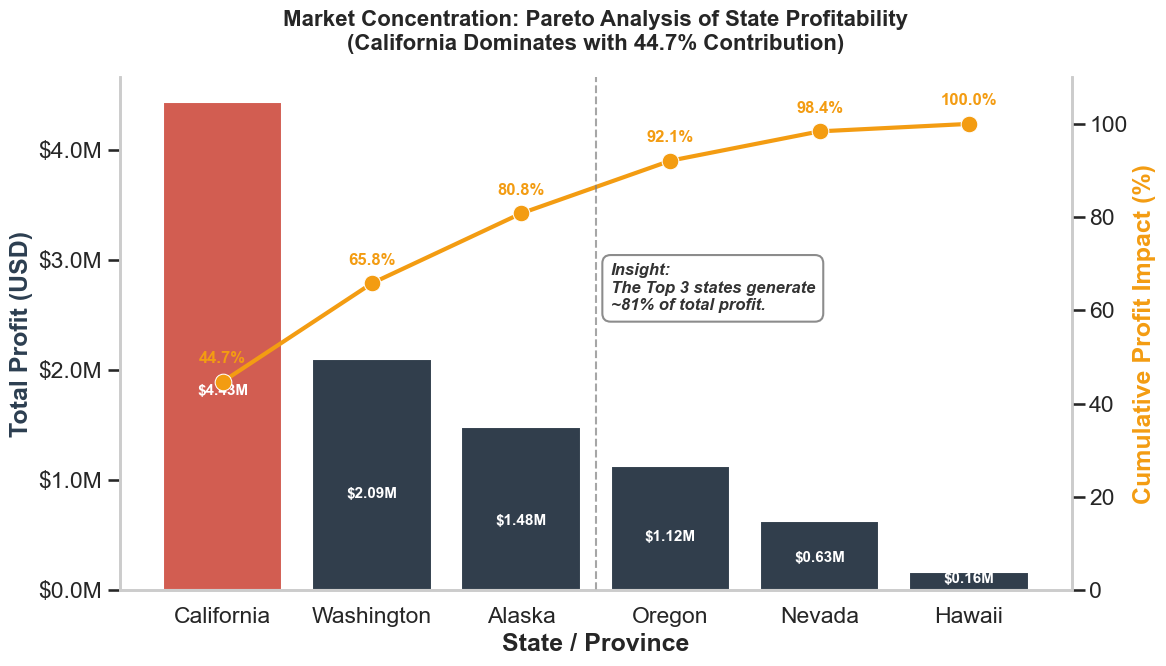

In [68]:
# 1. Calculate the cumulative percentage for the Pareto line
state_sales['cumulative_profit_pct'] = state_sales['state_impact_on_profits'].cumsum()

# 2. Setup the figure
fig, ax1 = plt.subplots(figsize=(12, 7))

# 3. Bar Chart (Left Axis) for Absolute Profit
# Logic: Highlight California as the dominant driver
state_colors = [highlight_color if state == 'California' else primary_color for state in state_sales['State Province']]

sns.barplot(
    data=state_sales,
    x='State Province',
    y='total_profit',
    palette=state_colors,
    order=state_sales['State Province'],
    ax=ax1
)

# 4. Format the Bar Chart (Y-axis in Millions)
ax1.set_ylabel('Total Profit (USD)', color=primary_color, fontweight='bold')
ax1.yaxis.set_major_formatter(FuncFormatter(currency_formatter))
ax1.set_xlabel('State / Province', fontweight='bold')

# Add exact profit values inside the bars
for p in ax1.patches:
    height = p.get_height() #type: ignore
    ax1.text(p.get_x() + p.get_width()/2., height * 0.4,  #type: ignore
             f'${height/1e6:.2f}M', 
             ha="center", color='white', fontweight='bold', fontsize=11)

# 5. Line Chart (Right Axis) for Cumulative Impact (Pareto Line)
ax2 = ax1.twinx()
line_color = '#f39c12'  # Contrasting orange/yellow for visibility

sns.lineplot(
    data=state_sales,
    x='State Province',
    y='cumulative_profit_pct',
    color=line_color,
    marker='o', markersize=12, linewidth=3,
    ax=ax2,
    sort=False
)

# 6. Format the Line Chart
ax2.set_ylabel('Cumulative Profit Impact (%)', color=line_color, fontweight='bold')
ax2.set_ylim(0, 110)

# Add cumulative percentage labels on the data points
for i, pct in enumerate(state_sales['cumulative_profit_pct']):
    ax2.text(i, pct + 4, f'{pct:.1f}%', 
             color=line_color, fontweight='bold', fontsize=12, ha='center')

# 7. Add Visual Storytelling Elements (The "Top 3 = 81%" Insight)
# Draw a vertical line after the 3rd state (index 2)
ax2.axvline(x=2.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

# Add an annotation box explaining the insight
ax2.text(2.6, 60, 'Insight:\nThe Top 3 states generate\n~81% of total profit.', 
         fontsize=12, style='italic', color='#333333', fontweight='bold',
         bbox=dict(facecolor='white', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

# 8. Final Layout Adjustments
plt.title('Market Concentration: Pareto Analysis of State Profitability\n(California Dominates with 44.7% Contribution)', pad=20)
ax1.grid(False)
ax2.grid(False)

sns.despine(right=False)
plt.tight_layout()
plt.show()

### City Visualization

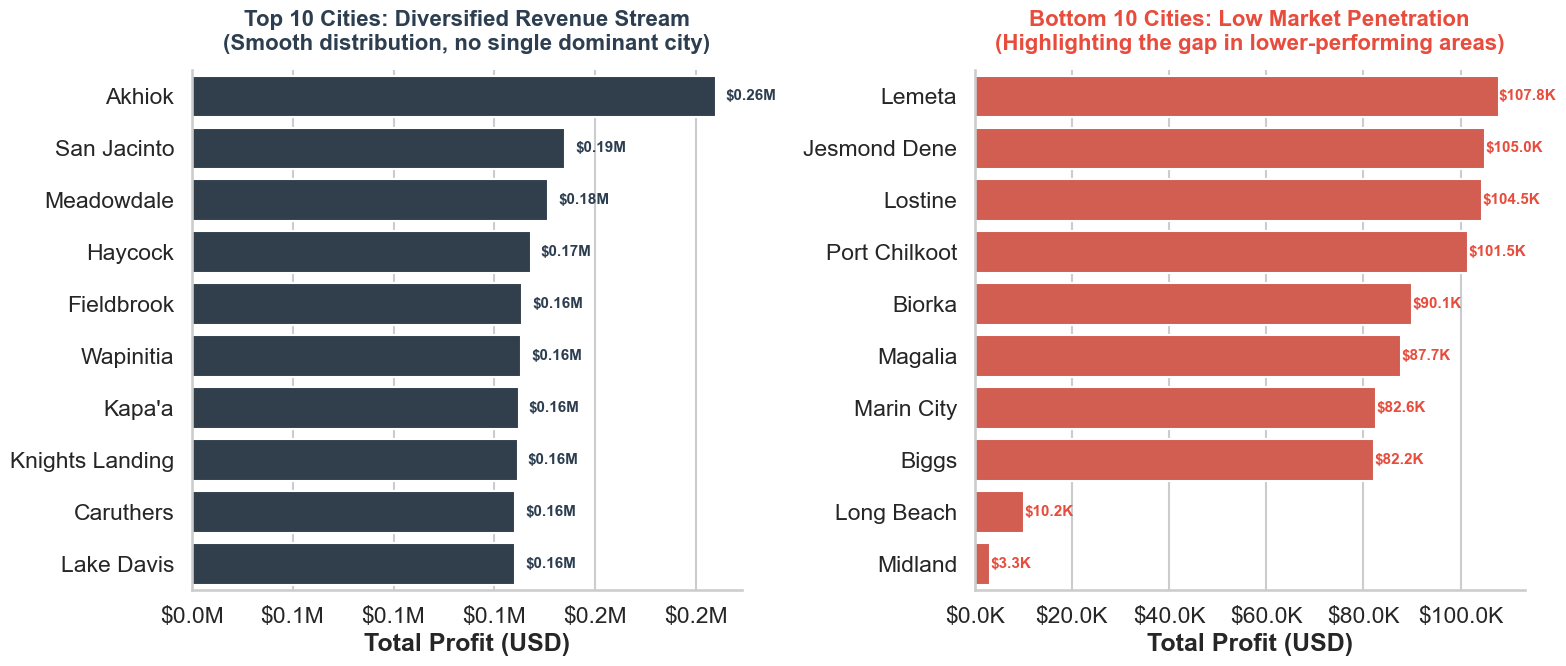

In [69]:
top_10_cities = city_sales.head(10).copy()

positive_cities = city_sales[city_sales['total_profit'] > 0]
bottom_10_cities = positive_cities.tail(10).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# ==========================================
# LEFT CHART: Top 10 Cities (Risk Diversification)
# ==========================================
sns.barplot(
    data=top_10_cities,
    x='total_profit',
    y='City',
    color=primary_color,
    order=top_10_cities['City'],
    ax=ax1
)

ax1.set_title('Top 10 Cities: Diversified Revenue Stream\n(Smooth distribution, no single dominant city)', 
              color=primary_color, fontweight='bold', pad=15)
ax1.set_xlabel('Total Profit (USD)', fontweight='bold')
ax1.set_ylabel('')
ax1.xaxis.set_major_formatter(FuncFormatter(currency_formatter))

# Add data labels for the Top 10
for p in ax1.patches:
    width = p.get_width()
    ax1.text(width + 5000, p.get_y() + p.get_height()/2, 
             f'${width/1e6:.2f}M', 
             va="center", color=primary_color, fontweight='bold', fontsize=11)

# ==========================================
# RIGHT CHART: Bottom 10 Cities (Market Gap)
# ==========================================
sns.barplot(
    data=bottom_10_cities,
    x='total_profit',
    y='City',
    color=highlight_color,
    order=bottom_10_cities['City'],
    ax=ax2
)

ax2.set_title('Bottom 10 Cities: Low Market Penetration\n(Highlighting the gap in lower-performing areas)', 
              color=highlight_color, fontweight='bold', pad=15)
ax2.set_xlabel('Total Profit (USD)', fontweight='bold')
ax2.set_ylabel('')

def thousands_formatter(x, pos):
    return f'${x/1e3:.1f}K'

ax2.xaxis.set_major_formatter(FuncFormatter(thousands_formatter))

for p in ax2.patches:
    width = p.get_width()
    ax2.text(width + 50, p.get_y() + p.get_height()/2, 
             f'${width/1e3:.1f}K', 
             va="center", color=highlight_color, fontweight='bold', fontsize=11)


sns.despine()
plt.tight_layout()
plt.show()

## products analysis

In [29]:
product_sales = merge_df.groupby(['Stock Item Key', 'Stock Item']) \
    .agg(
        total_quantity=('Quantity', 'sum'),
        total_profit=('Profit', 'sum'),
        total_revenue=('Total Including Tax', 'sum')
    ) \
    .sort_values(by='total_profit', ascending=False) \
    .reset_index(drop=False)
product_sales[['total_quantity', 'total_profit', 'total_revenue']] = \
    product_sales[['total_quantity', 'total_profit', 'total_revenue']].round(1).astype(int)

In [30]:
product_sales['product_impact_on_profits'] = ((product_sales['total_profit'] / product_sales['total_profit'].sum()) * 100).round(2)

In [31]:
product_sales['profit_margin'] = (product_sales['total_profit'] / product_sales['total_revenue']).round(2)

In [32]:
product_sales.shape

(227, 7)

In [33]:
product_sales.head(20)

,Stock Item Key,Stock Item,total_quantity,total_profit,total_revenue,product_impact_on_profits,profit_margin
0,59,20 mm Double sided bubble wrap 50m,7320,673440,909144,6.79,0.74
1,5,Air cushion machine (Blue),631,478929,1378009,4.83,0.35
2,53,10 mm Anti static bubble wrap (Blue) 50m,8750,472500,996187,4.76,0.47
3,56,32 mm Double sided bubble wrap 50m,6870,364110,884856,3.67,0.41
4,47,32 mm Anti static bubble wrap (Blue) 50m,6010,348580,725707,3.51,0.48
5,62,10 mm Double sided bubble wrap 50m,5770,282730,696727,2.85,0.41
6,50,20 mm Anti static bubble wrap (Blue) 50m,5760,270720,675648,2.73,0.40
7,1,Void fill 400 L bag (White) 400L,8110,194640,466325,1.96,0.42
8,48,32 mm Anti static bubble wrap (Blue) 20m,7500,187500,414000,1.89,0.45
9,51,20 mm Anti static bubble wrap (Blue) 20m,6880,165120,356040,1.66,0.46


In [34]:
product_sales.tail(10)

,Stock Item Key,Stock Item,total_quantity,total_profit,total_revenue,product_impact_on_profits,profit_margin
217,172,Developer joke mug - this code was generated by a tool (White),539,4581,8058,0.05,0.57
218,107,Superhero action jacket (Blue) XL,570,4560,19665,0.05,0.23
219,113,Superhero action jacket (Blue) 3XS,617,3702,17738,0.04,0.21
220,10,Packing knife with metal insert blade (Yellow) 18mm,3085,3702,8514,0.04,0.43
221,110,Superhero action jacket (Blue) S,613,3678,17623,0.04,0.21
222,11,Packing knife with metal insert blade (Yellow) 9mm,3510,3474,7629,0.04,0.46
223,76,Halloween zombie mask (Light Brown) L,7248,-7248,150033,-0.07,-0.05
224,75,Halloween zombie mask (Light Brown) XL,7884,-7884,163198,-0.08,-0.05
225,78,Halloween zombie mask (Light Brown) S,8904,-8904,184312,-0.09,-0.05
226,77,Halloween zombie mask (Light Brown) M,9024,-9024,186796,-0.09,-0.05


In [35]:
product_sales[['profit_margin']].value_counts().head(5)

profit_margin
0.57             46
0.53             17
0.65             15
0.40             14
0.43             13
Name: count, dtype: int64

In [36]:
product_sales.loc[0:23,['product_impact_on_profits']].sum()

product_impact_on_profits    50.57
dtype: float64

In [37]:
product_sales.loc[24:226,['product_impact_on_profits']].sum()

product_impact_on_profits    49.45
dtype: float64

In [38]:
product_sales['product_impact_on_profits'].sum()

np.float64(100.02000000000001)

#### Product Insights
- The 20mm thick, 50m long double-sided bubble wrap achieves the highest profit and profit margin compared to all other products.
- Profit distribution across products is moderately concentrated, as the top **24** products contribute only around **50%** of total profit.
- Profit margins across most products are relatively consistent, typically ranging between **40%** and **65%**, indicating a stable and standardized pricing structure.

## Products Visualization 

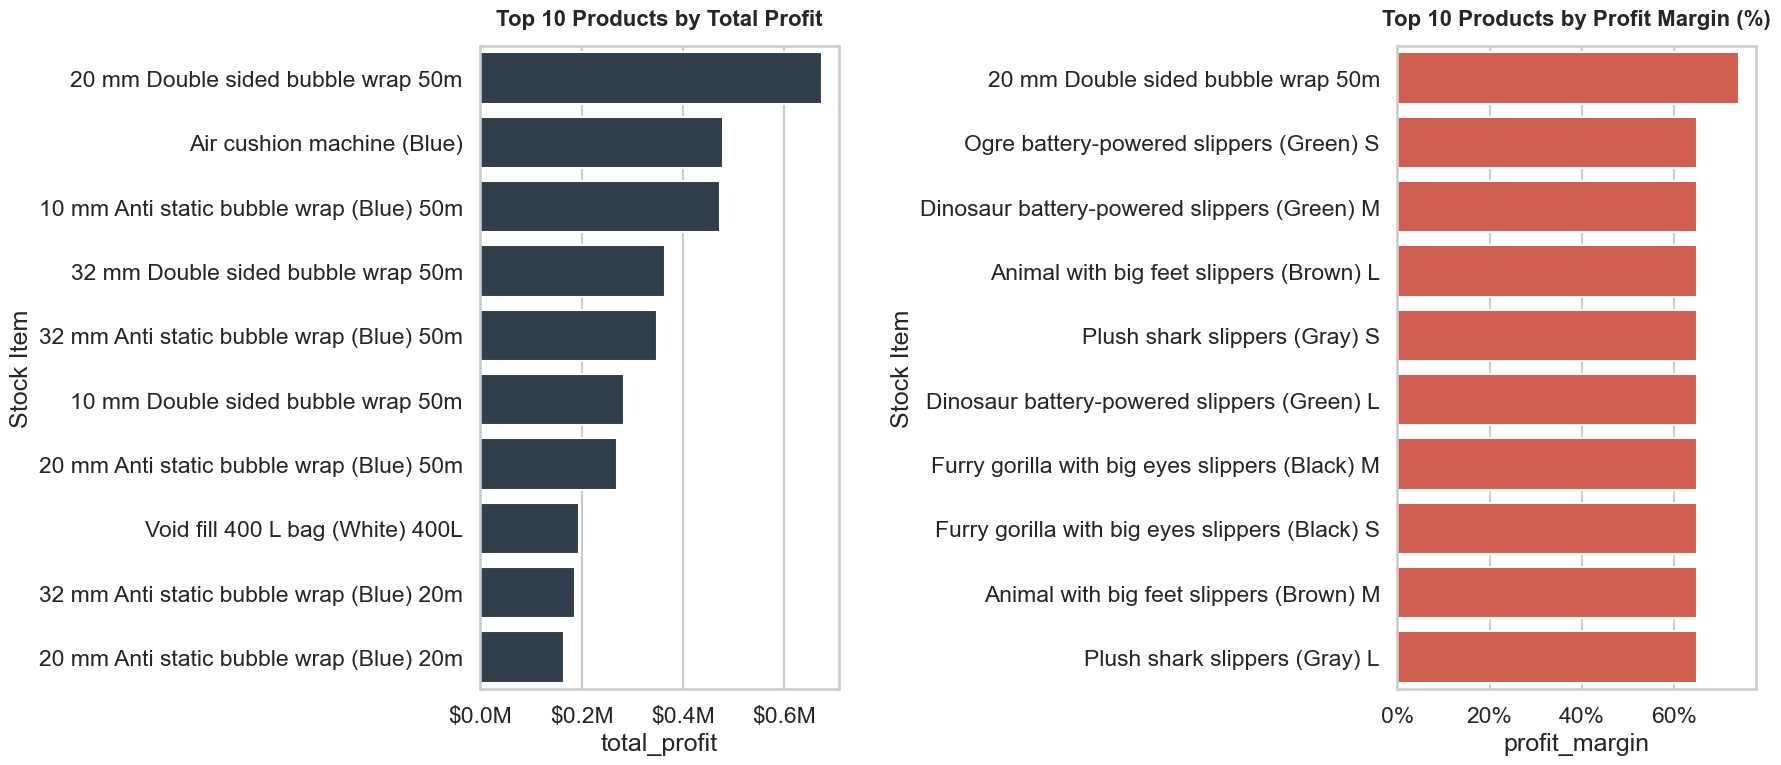

In [73]:
# Create two professional bar charts side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# 1. Left Chart: Profit Leaders
top_profit = product_sales.head(10)
sns.barplot(data=top_profit, x='total_profit', y='Stock Item', color=primary_color, ax=ax1)
ax1.set_title('Top 10 Products by Total Profit', fontweight='bold', pad=15)
ax1.xaxis.set_major_formatter(FuncFormatter(currency_formatter))

# 2. Right Chart: Efficiency Leaders (Margin)
top_margin = product_sales.sort_values('profit_margin', ascending=False).head(10)
sns.barplot(data=top_margin, x='profit_margin', y='Stock Item', color=highlight_color, ax=ax2)
ax2.set_title('Top 10 Products by Profit Margin (%)', fontweight='bold', pad=15)
ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x*100:.0f}%'))

plt.tight_layout()
plt.show()

## Seasonality Analysis

In [39]:
date_sales = merge_df.groupby(['Date'])\
    [['Quantity', 'Total Including Tax', 'Profit']].\
    agg(
        total_quantity=('Quantity', 'sum'),
        avg_quantity=('Quantity', 'mean'),
        total_profit=('Profit', 'sum'),
        total_revenue=('Total Including Tax', 'sum')).\
    sort_values(by='total_profit', ascending=False).reset_index(drop=False)

date_sales[['total_quantity', 'total_profit', 'total_revenue']] = \
    date_sales[['total_quantity', 'total_profit', 'total_revenue']].round().astype(int)

In [40]:
years = date_sales['Date'].dt.year
months = date_sales['Date'].dt.month_name()
month_num = date_sales['Date'].dt.month

date_sales.insert(1, 'Year', years)
date_sales.insert(2, 'Month', months)
date_sales.insert(3, 'Month_Num', month_num)

In [41]:
date_sales.shape

(1064, 8)

In [42]:
date_sales.head(10)

,Date,Year,Month,Month_Num,total_quantity,avg_quantity,total_profit,total_revenue
0,2014-07-22,2014,July,7,3041,44.072464,33282,70539
1,2016-05-19,2016,May,5,2898,51.750000,33000,78161
2,2013-11-18,2013,November,11,2490,37.727273,32575,79536
3,2015-03-16,2015,March,3,1487,36.268293,30806,69634
4,2014-06-06,2014,June,6,1425,33.928571,29782,59076
5,2013-09-05,2013,September,9,1932,56.823529,29770,58783
6,2015-02-03,2015,February,2,2005,29.925373,29087,62132
7,2013-12-27,2013,December,12,2289,37.524590,28650,55513
8,2015-02-10,2015,February,2,2435,39.918033,28417,65855
9,2015-09-08,2015,September,9,1355,37.638889,27390,69082


In [43]:
yearly = date_sales.groupby("Year").agg({
    "total_quantity": "sum",
    "total_profit": "sum",
    "total_revenue": "sum"
}).reset_index()

In [ ]:
monthly = date_sales.groupby(["Month", "Month_Num"]).agg({
    "total_quantity": "sum",
    "total_profit": "sum",
    "total_revenue": "sum"
}).reset_index().sort_values(by='Month_Num', ascending=True)

In [45]:
year_month = date_sales.groupby(["Year", "Month_Num", "Month"]).agg({
    "total_quantity": "sum",
    "total_profit": "sum",
    "total_revenue": "sum"
}).reset_index().sort_values(["Year", "Month_Num"])

In [46]:
yearly

,Year,total_quantity,total_profit,total_revenue
0,2013,277812,2637737,6046649
1,2014,298948,2908055,6719930
2,2015,314145,3162083,7300033
3,2016,137765,1216015,2788454


<Axes: xlabel='Year'>

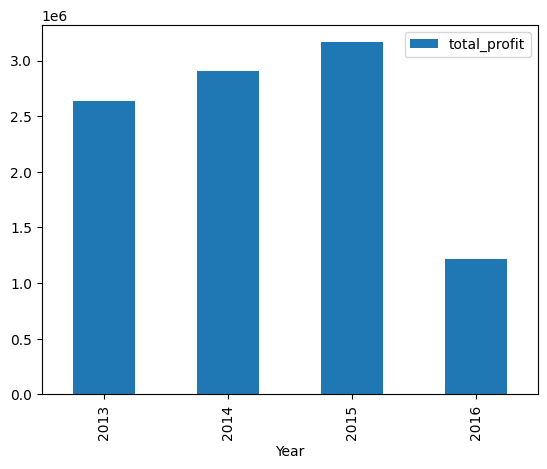

In [47]:
yearly.plot.bar(x='Year', y='total_profit')

In [48]:
monthly

,Month,Month_Num,total_quantity,total_profit,total_revenue
4,January,1,103196,973641,2186739
3,February,2,84709,855629,1987009
7,March,3,105488,1028671,2328098
0,April,4,103430,1017268,2336388
8,May,5,107738,1039070,2416193
6,June,6,71252,694013,1632979
5,July,7,91169,813004,1870902
1,August,8,65086,597181,1411374
11,September,9,69570,717776,1637061
10,October,10,77849,761822,1784246


<Axes: xlabel='Month'>

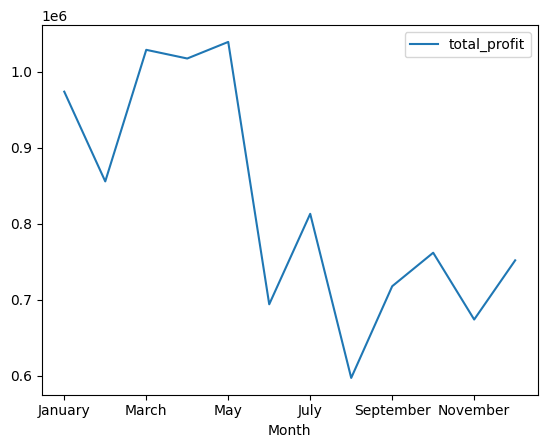

In [49]:
monthly.plot.line(x='Month', y='total_profit') #type: ignore

In [50]:
year_month

,Year,Month_Num,Month,total_quantity,total_profit,total_revenue
0,2013,1,January,22223,203818,464012
1,2013,2,February,16749,161464,374312
2,2013,3,March,20440,213304,469155
3,2013,4,April,25354,246956,580971
4,2013,5,May,27148,269846,602088
5,2013,6,June,26513,241101,576926
6,2013,7,July,27754,226203,523202
7,2013,8,August,23240,188158,449198
8,2013,9,September,20394,221994,493244
9,2013,10,October,23497,233554,557645


In [51]:
pivot = date_sales.pivot_table(
    index="Month_Num",
    columns="Year",
    values="total_profit",
    aggfunc="sum"
)

In [52]:
pivot

Year,2013,2014,2015,2016
Month_Num,,,,
1,203818.0,246264.0,247653.0,275906.0
2,161464.0,198811.0,282045.0,213309.0
3,213304.0,276855.0,282141.0,256371.0
4,246956.0,255261.0,297921.0,217130.0
5,269846.0,274097.0,241828.0,253299.0
6,241101.0,201648.0,251264.0,NaN
7,226203.0,291324.0,295477.0,NaN
8,188158.0,199110.0,209913.0,NaN
9,221994.0,239474.0,256308.0,NaN


### Seasonality
- 2016 data is incomplete (only Jan–May), so it must be excluded from yearly comparisons
Any analysis including 2016 yearly totals will lead to misleading conclusions

#### Yearly Trend
- There is consistent growth from 2013 to 2015 (~10% annually)
- 2015 is the best-performing year in terms of revenue and profit
- The growth pattern is stable and organic, not driven by anomalies

#### Seasonality (Core Insight)
- A strong and consistent seasonal pattern exists across years
- The period from March to May (Q2) is the peak season
- This period consistently generates the highest revenue and profit

#### Low Season
- June to August is the weakest period (low season)
- August is consistently the lowest-performing month
- There is a clear drop immediately after the peak season

#### Seasonal Structure
- January–February: moderate to low performance
- March–May: strong upward trend (peak)
- June–August: significant decline
- September–December: gradual recovery

## Seasonality Visualization

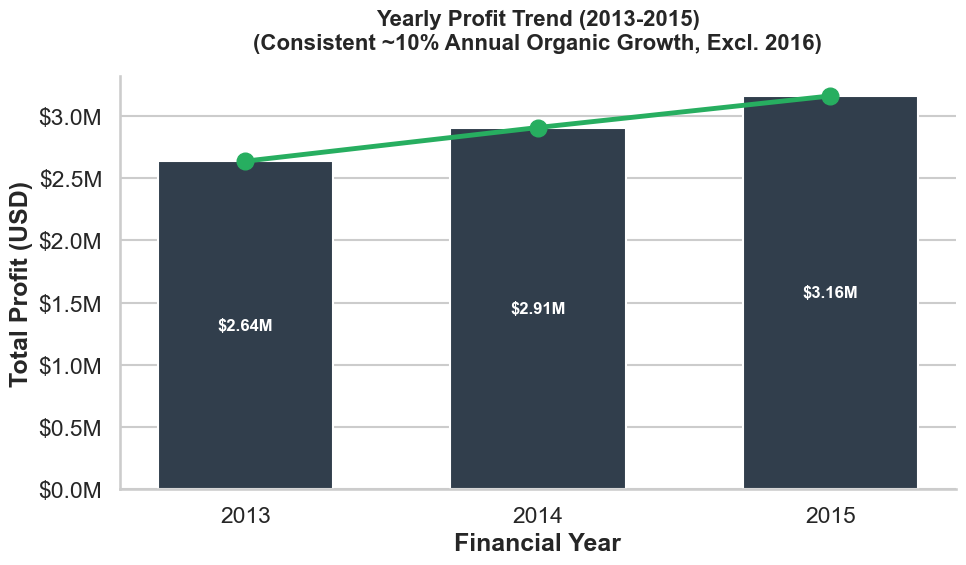

In [ ]:
# 1. Filter out 2016
valid_years = yearly[yearly['Year'] != 2016].copy()

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Plot the yearly profit (Convert Year to string to force categorical alignment)
sns.barplot(
    data=valid_years, 
    x=valid_years['Year'].astype(str), 
    y='total_profit', 
    color=primary_color, 
    width=0.6, # Make bars slightly thinner for a more elegant look
    ax=ax
)

# 3. Add the Trendline using exact bar coordinates to prevent misalignment
x_coords = [p.get_x() + p.get_width() / 2.0 for p in ax.patches] # type: ignore
y_coords = valid_years['total_profit'].values

ax.plot(
    x_coords, 
    y_coords, # type: ignore
    color=success_color, 
    marker='o', 
    markersize=12, 
    linewidth=3.5, 
    zorder=5 # Force the line to stay on top of the bars
)

# 4. Format axes and add labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Yearly Profit Trend (2013-2015)\n(Consistent ~10% Annual Organic Growth, Excl. 2016)', 
             fontweight='bold', pad=20)
ax.set_xlabel('Financial Year', fontweight='bold')
ax.set_ylabel('Total Profit (USD)', fontweight='bold')

# 5. Add values INSIDE the middle of the bars to prevent overlap with the line
for p in ax.patches:
    height = p.get_height() # type: ignore
    ax.text(p.get_x() + p.get_width()/2., height * 0.5, # type: ignore
            f'${height/1e6:.2f}M', 
            ha="center", va="center", color='white', fontweight='bold', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

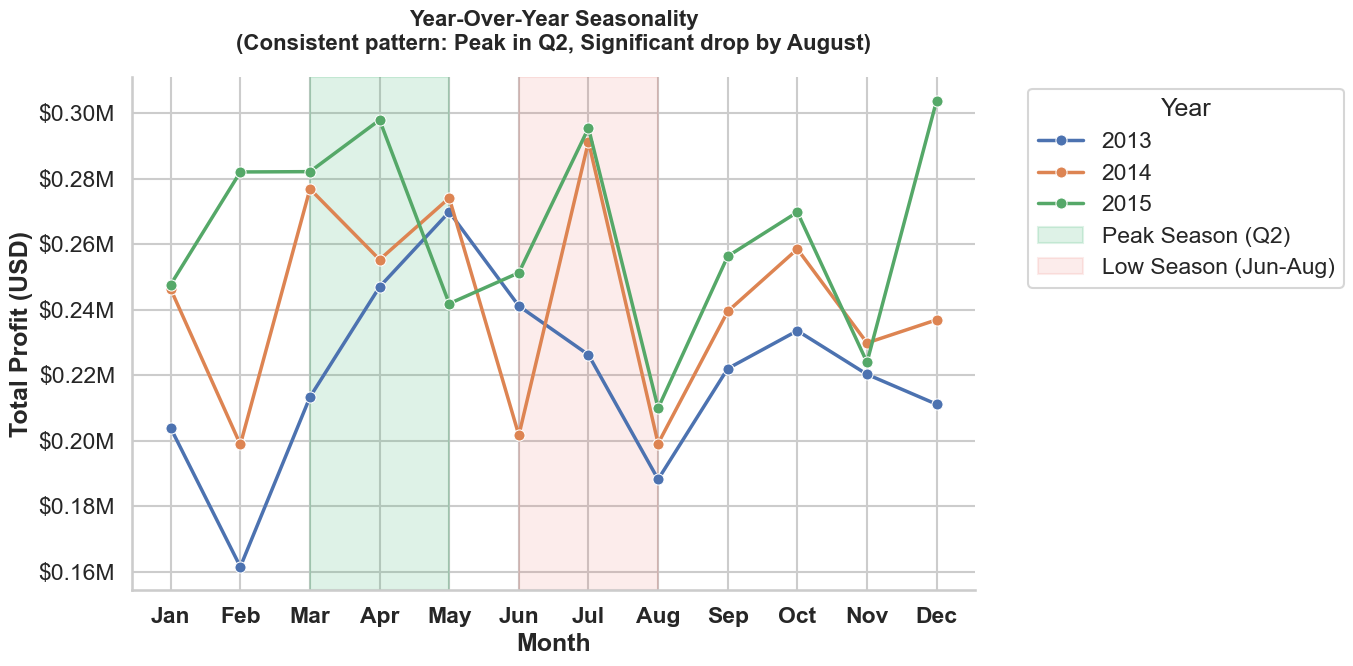

In [76]:
import calendar

fig, ax = plt.subplots(figsize=(14, 7))

# 1. Prepare data using the pivot table, excluding 2016
pivot_valid = pivot.drop(columns=[2016], errors='ignore')

# 2. Plot a line for each year
for year in pivot_valid.columns:
    sns.lineplot(
        x=pivot_valid.index, 
        y=pivot_valid[year], 
        marker='o', markersize=8, linewidth=2.5, 
        label=str(year), 
        ax=ax
    )

# 3. Highlight the Peak Season (March - May)
ax.axvspan(3, 5, color=success_color, alpha=0.15, label='Peak Season (Q2)')

# 4. Highlight the Low Season (June - August)
ax.axvspan(6, 8, color=highlight_color, alpha=0.1, label='Low Season (Jun-Aug)')

# 5. Format X-axis to show Month abbreviations instead of numbers
month_abbr = [calendar.month_abbr[i] for i in range(1, 13)]
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_abbr, fontweight='bold')

# 6. Format Y-axis and Title
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.2f}M'))
ax.set_title('Year-Over-Year Seasonality\n(Consistent pattern: Peak in Q2, Significant drop by August)', 
             fontweight='bold', pad=20)
ax.set_xlabel('Month', fontweight='bold')
ax.set_ylabel('Total Profit (USD)', fontweight='bold')

# Place legend outside
ax.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

C:\Users\LOQ\AppData\Local\Temp\ipykernel_20172\1649866246.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


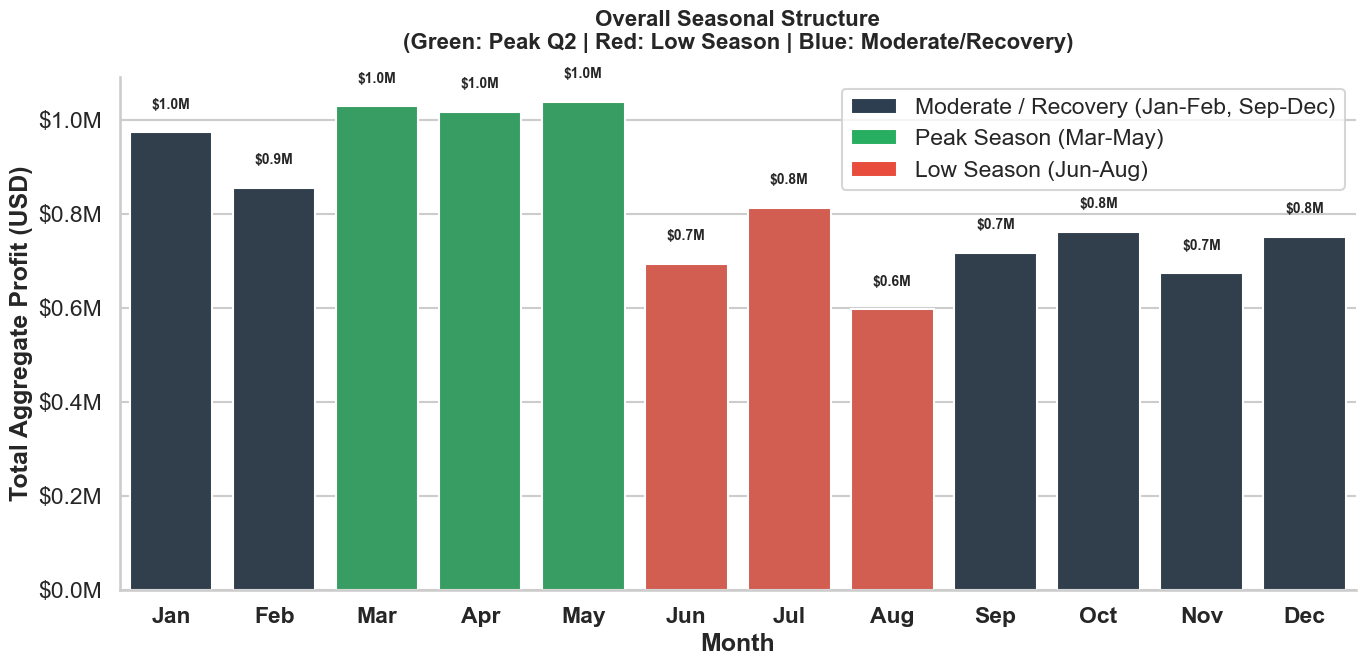

In [77]:
fig, ax = plt.subplots(figsize=(14, 7))

# 1. Define color coding logic based on your 4 phases
def get_phase_color(month_num):
    if month_num in [3, 4, 5]:     # Peak
        return success_color
    elif month_num in [6, 7, 8]:   # Low Season
        return highlight_color
    else:                          # Moderate/Recovery (1,2 and 9,10,11,12)
        return primary_color

phase_colors = [get_phase_color(m) for m in monthly['Month_Num']]

# 2. Plot the overall monthly profit
sns.barplot(
    data=monthly, 
    x='Month_Num', 
    y='total_profit', 
    palette=phase_colors, 
    ax=ax
)

# 3. Format X-axis with Month names
ax.set_xticks(range(0, 12))
ax.set_xticklabels(month_abbr, fontweight='bold')

# 4. Add data labels for clarity
for p in ax.patches:
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 50000, 
            f'${height/1e6:.1f}M', 
            ha="center", fontweight='bold', fontsize=10)

# 5. Format Y-axis and Title
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
ax.set_title('Overall Seasonal Structure\n(Green: Peak Q2 | Red: Low Season | Blue: Moderate/Recovery)', 
             fontweight='bold', pad=20)
ax.set_xlabel('Month', fontweight='bold')
ax.set_ylabel('Total Aggregate Profit (USD)', fontweight='bold')

# 6. Add Custom Legend to explain the colors
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=primary_color, label='Moderate / Recovery (Jan-Feb, Sep-Dec)'),
    Patch(facecolor=success_color, label='Peak Season (Mar-May)'),
    Patch(facecolor=highlight_color, label='Low Season (Jun-Aug)')
]
ax.legend(handles=legend_elements, loc='upper right')

sns.despine()
plt.tight_layout()
plt.show()